# Dask-native OD connectivity with `hex_connectivity_dask`

This notebook demonstrates how to efficiently compute origin–destination (OD)
connectivity from trajectory data using a lazy, dask-backed pipeline. The key
benefit: you can filter (e.g., by observation step) **before** computation to
avoid materialising the full trajectory table.

The workflow:

1. Open a dask-backed xarray Dataset (chunked along `traj`).
2. Build a lazy OD table with `hex_connectivity_dask`, one row per `(traj, obs)` pair.
3. Filter to select the target observation step(s).
4. Call `.compute()` to aggregate and materialise counts.
5. Attach destination hex geometries and visualise.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from importlib.resources import files

import numpy as np
import pandas as pd
import xarray as xr
import dask.dataframe as dd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader

from hextraj import HexProj
from hextraj.hex_analysis import hex_connectivity_dask
from hextraj.hex_id import INVALID_HEX_ID

In [2]:
coastlines = gpd.read_file(
    shpreader.natural_earth(resolution="10m", category="physical", name="coastline")
)

## Load data

The bundled NW Shelf dataset contains 5 000 Lagrangian particle trajectories
advected for 20 observation steps (roughly three weeks) on the NW European Shelf.
Dimensions are `(traj, obs)`. Variables `lon` and `lat` record particle positions;
some positions are `NaN` (particle became invalid).

Opening with `chunks={"traj": 500}` produces a dask-backed Dataset — the same
pattern used with a Zarr store. Chunking along `traj` means each partition
contains complete trajectories, making `isel(obs=...)` a cheap in-chunk slice.

In [3]:
p = files("hextraj.data.trajs").joinpath("nwshelf.nc")
ds = xr.open_dataset(p, chunks={"traj": 500})
ds

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_87874/3848662866.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "traj" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(p, chunks={"traj": 500})


<xarray.Dataset> Size: 4MB
Dimensions:      (traj: 5000, obs: 20)
Dimensions without coordinates: traj, obs
Data variables:
    time         (traj, obs) datetime64[ns] 800kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    trajectory   (traj, obs) float64 800kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    lon          (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    lat          (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    z            (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    temperature  (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    salinity     (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    land         (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
Attributes:
    feature_type:           trajectory
    Conventions:            CF-1.6/CF-1.7
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_version:        2.3.1
    parcels_mesh:           spherical

## Build HexProj

A Lambert Azimuthal Equal-Area projection centred near the NW Shelf domain
midpoint (−3°E, 54°N) minimises distortion across the region. A hex size of
40 km gives a fine spatial resolution — each hexagon covers roughly 4 200 km²,
comparable to a 65 × 65 km grid cell.

In [4]:
hp = HexProj(
    projection_name="laea",
    lon_origin=-3.0,
    lat_origin=54.0,
    hex_size_meters=40_000,
    hex_orientation="flat",
)
hp

HexProj(projection_name='laea', lon_origin=-3.0, lat_origin=54.0, hex_size_meters=40000, hex_orientation='flat', )

## Build the lazy connectivity table

`hex_connectivity_dask` builds a lazy dask DataFrame with one row per
`(traj, obs)` combination. No computation happens here — the function
wires together the dask task graph without reading any data.

The result always contains:

| Column | Description |
|--------|-------------|
| `from_id` | hex ID at obs=0 for each trajectory (the release hex) |
| `to_id` | hex ID at the current obs step |
| `obs` | observation index (0 … 19) |
| `traj` | trajectory index |

`INVALID_HEX_ID = -1` appears in `from_id` or `to_id` wherever the particle
position is `NaN` (became invalid early and is absent from subsequent analysis).

In [5]:
ddf = hex_connectivity_dask(ds, hp)
ddf

,traj,obs,from_id,to_id
npartitions=10,,,,
0,int64,int64,int64,int64
10000,...,...,...,...
...,...,...,...,...
90000,...,...,...,...
99999,...,...,...,...


## Understanding laziness

A dask DataFrame is **lazy**: the function constructs a task graph describing the
computation without reading any data or executing it. You control when execution
happens — by calling `.compute()` — and you can filter the graph before that point
(e.g., select only one observation step) to avoid materialising the full table.

We can inspect the size of the task graph to verify the pipeline is fully encoded:

In [6]:
print(f"Number of tasks in the dask graph: {len(ddf.__dask_graph__())}")
print(f"Number of partitions: {ddf.npartitions}")

Number of tasks in the dask graph: 350
Number of partitions: 10


## Filter before compute

The user decides what to aggregate **before** calling `.compute()`. Here we
select only rows where `obs` equals the final observation step (obs=19). This
reduces the materialised data from the full `(traj × obs)` table to just the last
observation per trajectory — without triggering any I/O.

In [7]:
last_obs = int(ds["obs"].values[-1])
ddf_last = ddf[ddf["obs"] == last_obs]
print(f"After filter: {type(ddf_last).__name__} with obs={last_obs}")

After filter: DataFrame with obs=19


## Compute obs=0 → obs=19 connectivity

Now we materialise: group by `(from_id, to_id)`, count trajectories per pair,
then drop rows involving `INVALID_HEX_ID` (particles that left the domain at
either the start or end of their trajectory).

The single `.compute()` call executes the full pipeline: read chunks from disk,
project lon/lat to hex IDs, filter, and aggregate.

In [8]:
od = (
    ddf_last
    .groupby(["from_id", "to_id"])
    .size()
    .compute()
)
od.name = "count"

In [9]:
od = od[
    (od.index.get_level_values("from_id") != INVALID_HEX_ID)
    & (od.index.get_level_values("to_id") != INVALID_HEX_ID)
]

### Top-10 OD pairs

Pairs where `from_id == to_id` represent trajectories that stayed in the same hex
from release to the final step — these dominate the ranking and indicate strong
retention in their release hexagons.

In [10]:
od.nlargest(10).to_frame()

,,count
from_id,to_id,
80,80,12
112,145,12
174,174,12
391,391,12
69,125,11
59,59,11
85,85,10
143,180,10
140,140,10


## Visualise as a choropleth heatmap

The plots below show connectivity from a fixed origin hex in the central North Sea (~4°E, 57°N). This location sits in the open northern North Sea, away from coastal boundaries, giving a clean picture of offshore dispersal driven by the large-scale circulation. With 40 km hexes, the origin region is well-resolved and contains enough trajectories for statistically meaningful destination maps.

`hp.to_geodataframe` accepts an array of hex IDs and returns a GeoDataFrame with hexagonal Polygon geometries in EPSG:4326.

In [11]:
from_hex = 175  # central North Sea, ~4°E 57°N (200 trajectories)

In [12]:
dest = od.xs(from_hex, level="from_id")
dest = dest[dest.index != INVALID_HEX_ID]
dest_ids = dest.index.values

dest_gdf = hp.to_geodataframe(dest_ids, count=dest.values)
dest_gdf = dest_gdf[dest_gdf.geometry.notna()]
dest_gdf.head()

,count,geometry
140,2,"POLYGON ((3.58046 56.94363, 3.20205 56.6502, 2..."
175,7,"POLYGON ((4.62351 57.19864, 4.23426 56.90838, ..."
138,1,"POLYGON ((4.49912 56.58035, 4.11742 56.28969, ..."


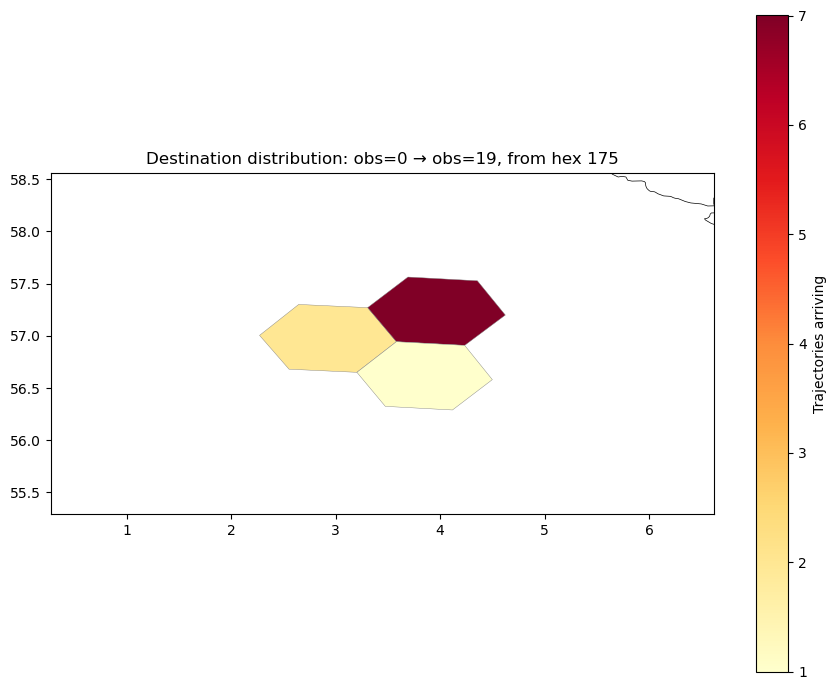

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

dest_gdf.plot(
    column="count",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="grey",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Trajectories arriving", "orientation": "vertical"},
)
coastlines.plot(ax=ax, color="black", linewidth=0.5)

bounds = dest_gdf.total_bounds
ax.set_xlim(bounds[0] - 2, bounds[2] + 2)
ax.set_ylim(bounds[1] - 1, bounds[3] + 1)
ax.set_title(f"Destination distribution: obs=0 → obs=19, from hex {from_hex}")
plt.tight_layout()
plt.show()

## Multi-obs view: spreading over time

Applying the same connectivity analysis at multiple observation steps shows how
trajectories spread spatially over time. By filtering to each step before
computing, we avoid materialising the entire lazy DataFrame — the filter
predicate is added to the task graph before execution.

In [14]:
obs_steps = [5, 10, 15, 19]

od_by_obs = {}
for k in obs_steps:
    od_k = (
        ddf[ddf["obs"] == k]
        .groupby(["from_id", "to_id"])
        .size()
        .compute()
    )
    od_k.name = "count"
    od_k = od_k[
        (od_k.index.get_level_values("from_id") != INVALID_HEX_ID)
        & (od_k.index.get_level_values("to_id") != INVALID_HEX_ID)
    ]
    od_by_obs[k] = od_k

print("Computed OD counts at obs steps:", list(od_by_obs.keys()))

Computed OD counts at obs steps: [5, 10, 15, 19]


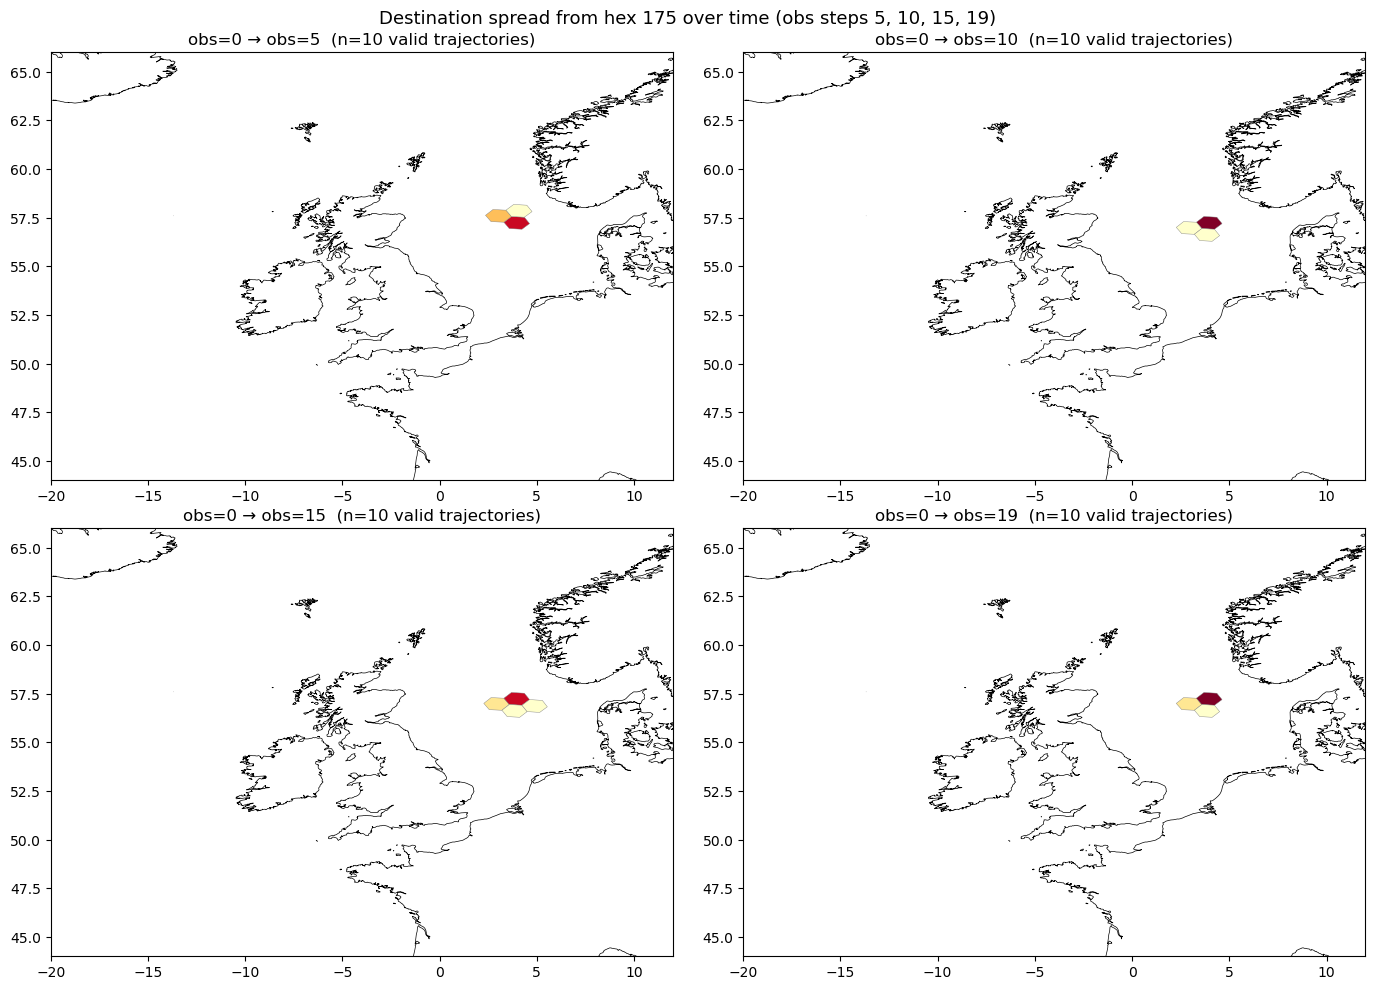

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, k in zip(axes.flat, obs_steps):
    od_k = od_by_obs[k]

    try:
        dest_k = od_k.xs(from_hex, level="from_id")
    except KeyError:
        dest_k = pd.Series(dtype=int, name="count")

    dest_k = dest_k[dest_k.index != INVALID_HEX_ID]

    if len(dest_k) > 0:
        dest_k_gdf = hp.to_geodataframe(dest_k.index.values, count=dest_k.values)
        dest_k_gdf = dest_k_gdf[dest_k_gdf.geometry.notna()]

        dest_k_gdf.plot(
            column="count",
            ax=ax,
            cmap="YlOrRd",
            edgecolor="grey",
            linewidth=0.3,
            vmin=1,
            vmax=od.xs(from_hex, level="from_id").max(),
            legend=False,
        )

    coastlines.plot(ax=ax, color="black", linewidth=0.5)

    n_traj = int(dest_k.sum()) if len(dest_k) > 0 else 0
    ax.set_xlim(-20, 12)
    ax.set_ylim(44, 66)
    ax.set_title(f"obs=0 → obs={k}  (n={n_traj} valid trajectories)")

fig.suptitle(
    f"Destination spread from hex {from_hex} over time (obs steps 5, 10, 15, 19)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Cumulative settling connectivity

A particle that can settle — recruit to a habitat, land on the seabed — performs
this action exactly once, at the first step where the condition is met. If the
probability of settling is equal at every observation step, then the probability
of settling **in hex $j$** is proportional to the total time spent in hex $j$.

For a particle released in hex $i$, let $n_{ij}$ be the total number of
`(traj, obs)` pairs for which `from_id` = $i$ and `to_id` = $j$ — i.e., the
cumulative visits to hex $j$ across all obs steps. The settling probability is:

$$P(\text{settles in } j \mid \text{released in } i)
  = \frac{n_{ij}}{\displaystyle\sum_{j'} n_{ij'}}$$

No weight column is needed: equal-probability settling reduces to counting visits.

This contrasts with the **endpoint view** (obs=0 → obs=19), which records only
where each particle ends up at the final step. Particles that pass through a hex
early and then leave contribute nothing to the endpoint count, even if they would
have settled there with high probability. The settling view integrates over the
entire trajectory.

### Compute settling connectivity

Group by `(from_id, to_id)` across all observation steps and count rows. The
full lazy DataFrame `ddf` is used — no pre-filtering by obs step.

In [16]:
settling = (
    ddf.groupby(["from_id", "to_id"])
    .size()
    .compute()
    .rename("settling_probability")
)

### Normalise per origin hex

Dividing by the total visit count out of each origin converts raw counts into
conditional probabilities: the fraction of visits to hex $j$ among all visits
from origin $i$. Each row of the resulting table sums to 1 over all valid
destinations.

In [17]:
settling_norm = settling / settling.groupby(level="from_id").transform("sum")

### Compare endpoint vs. settling connectivity

Two panels for the same origin hex `from_hex`:

- **Left**: endpoint connectivity — only trajectories that reach obs=19, showing
  where particles end up at the final step.
- **Right**: settling connectivity — the time-averaged fraction of visits to each
  hex, integrating over all obs steps.

A hex that particles pass through early and leave will appear in the right panel
but not in the left. Conversely, hexes that particles drift into only near the
end will dominate the left panel.

In [18]:
try:
    dest_endpoint = od.xs(from_hex, level="from_id")
except KeyError:
    dest_endpoint = pd.Series(dtype=float, name="count")

dest_endpoint = dest_endpoint[dest_endpoint.index != INVALID_HEX_ID]
dest_endpoint_norm = dest_endpoint / dest_endpoint.sum()

try:
    dest_settling = settling_norm.xs(from_hex, level="from_id")
except KeyError:
    dest_settling = pd.Series(dtype=float, name="settling_probability")

dest_settling = dest_settling[dest_settling.index != INVALID_HEX_ID]

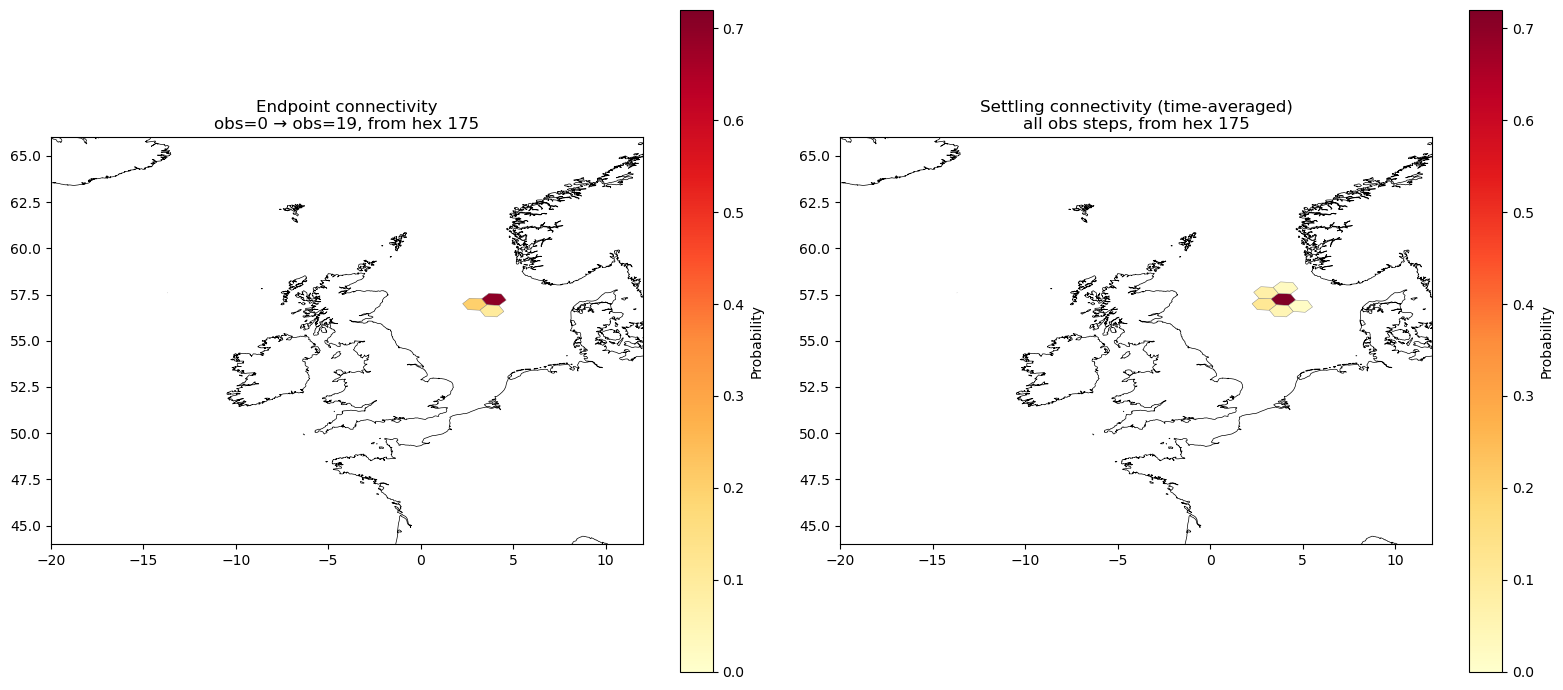

In [19]:
all_ids = np.union1d(dest_endpoint_norm.index.values, dest_settling.index.values)
vmax = max(dest_endpoint_norm.max(), dest_settling.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, values, title in zip(
    axes,
    [dest_endpoint_norm, dest_settling],
    [
        f"Endpoint connectivity\nobs=0 → obs=19, from hex {from_hex}",
        f"Settling connectivity (time-averaged)\nall obs steps, from hex {from_hex}",
    ],
):
    ids = values.index.values
    if len(ids) > 0:
        gdf = hp.to_geodataframe(ids, value=values.values)
        gdf = gdf[gdf.geometry.notna()]
        gdf.plot(
            column="value",
            ax=ax,
            cmap="YlOrRd",
            edgecolor="grey",
            linewidth=0.3,
            vmin=0,
            vmax=vmax,
            legend=True,
            legend_kwds={"label": "Probability", "orientation": "vertical"},
        )
    coastlines.plot(ax=ax, color="black", linewidth=0.5)
    ax.set_xlim(-20, 12)
    ax.set_ylim(44, 66)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Interpretation

The two panels show different aspects of the same trajectories. In the left panel,
only particles still valid at obs=19 contribute — particles that became invalid
early are absent from the count. The spatial pattern reflects where particles
happen to be at one particular moment.

The right panel accumulates visits across all 20 obs steps. A hex that particles
cross through at any point — even obs=1 — contributes to its settling probability.
Hexes close to the release point often receive more probability mass in the settling
view because particles spend more total time near their origin than they do near
any single distant destination. Conversely, distant hexes that particles reach only
late in the simulation may appear equally prominent in the endpoint panel but weaker
in the settling panel, because particles spent fewer steps there overall.

The settling view is the physically appropriate connectivity metric when the action
of interest — recruitment, deposition, colonisation — can happen at any step with
equal likelihood. The endpoint view is appropriate only when the relevant moment is
fixed (e.g. arrival at a sampling date).